# UAV Laser Scanning Test Case

This notebook gives a brief overview over UAVLS occlusion mapping using OccPy.
The last Cell shows you how to execute the script from the command line using a JSON config file. 

First we import the relevant modules.

In [1]:
from occpy.OccPy import OccPy
from occpy import TerrainModel
import os
import argparse
from pathlib import Path

We now set our root folder to the folder where our data is stored.
We can now set the input parameters and read the trajectory file. 

In [4]:
root_folder = Path("C:/Users/an274/december/OccPy/data/UAVLS/")

test = OccPy(laz_in=os.path.join(root_folder, "Occpy_UAVLS_test_data.laz"),
             out_dir=os.path.join(str(root_folder.parent.parent), "output"),
             vox_dim=0.15,
             lower_threshold=1,
             points_per_iter=1000000,
             plot_dim=[2676541,
                       1246160,
                       540,
                       2676591,
                       1246210,
                       615])

test.read_trajectory_file(path2traj=os.path.join(root_folder, "test_traj.txt"),
                          delimiter=',',
                          hdr_time='Time[s]', hdr_x='Easting[m]', hdr_y='Northing[m]', hdr_z='Height[m]')

Now we can start the raytracing and save the outputs.

In [6]:
test.do_raytracing()

0.00%
!!!!! input laz file is not sorted along gps_time. The algorithm will still run. However, the performance will be greatly decreased as the entire content of the laz file has to be read into the system memory. If you have multi return data, consider sorting your laz data first, e.g. using LASTools lassort: lassort -i laz_in -gps_time -return_number -odix _sort -olaz -v !!!!
0.65%
1.30%
1.95%
2.60%
3.25%
3.90%
4.55%
5.19%
5.84%
6.49%
7.14%
7.79%
8.44%
9.09%
9.74%
10.39%
11.04%
11.69%
12.34%
12.99%
13.64%
14.29%
14.93%
15.58%
16.23%
16.88%
17.53%
18.18%
18.83%
19.48%
20.13%
20.78%
21.43%
22.08%
22.73%
23.38%
24.03%
24.67%
25.32%
25.97%
26.62%
27.27%
27.92%
28.57%
29.22%
29.87%
30.52%
31.17%
31.82%
32.47%
33.12%
33.76%
34.41%
35.06%
35.71%
36.36%
37.01%
37.66%
38.31%
38.96%
39.61%
40.26%
40.91%
41.56%
42.21%
42.86%
43.50%
44.15%
44.80%
45.45%
46.10%
46.75%
47.40%
48.05%
48.70%
49.35%
50.00%
50.65%
51.30%
51.95%
52.60%
53.24%
53.89%
54.54%
55.19%
55.84%
56.49%
57.14%
57.79%
58.44%
59.

Before we derive statistics and plot the results, we need to normalize the height using a digital terrain model and a digital surface model.

In [7]:
test.normalize_occlusion_output(input_folder=test.out_dir,
                                dtm_file=os.path.join(str(root_folder.parent), "DTM_FP05_swissAlti3D_10cm.tif"),
                                dsm_file=os.path.join(str(root_folder.parent), "DSM_FP05_swissSurface3D_10cm.tif"))

C:\Users\an274\AppData\Local\anaconda3\envs\occPy_dec\lib\site-packages\osgeo\gdal.py:311: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


Saving normalized output files into directory as .npy...


Now we can assess the results.

In [8]:
print(f"Total canopy volume of the plot: {test.TotalVolume * (test.vox_dim**3)} m3")
print(f"Total occluded volume of the plot: {test.TotalOcclusion * (test.vox_dim**3)} m3")
print(f"Average occlusion fraction: {test.OcclFrac2D.mean()}")
print(f"Max occlusion fraction: {test.OcclFrac2D.max()}")

Total canopy volume of the plot: 57548.096999999994 m3
Total occluded volume of the plot: 0.020249999999999997 m3
Average occlusion fraction: 0.0
Max occlusion fraction: 0.0


We can also visualize the results.

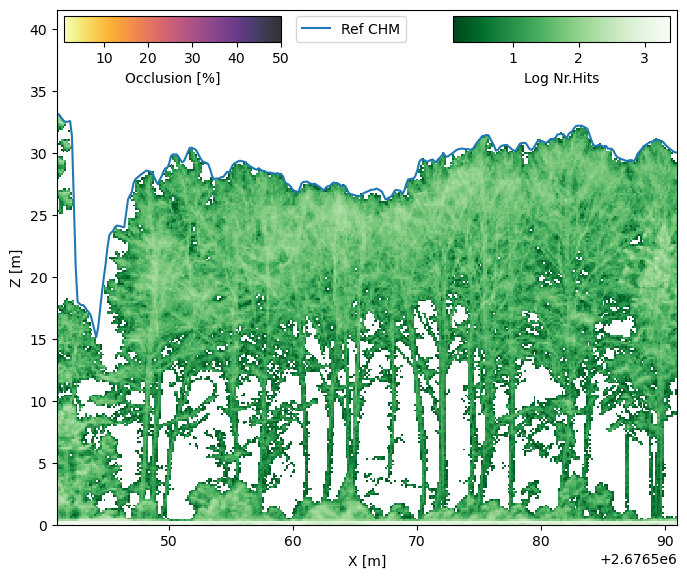

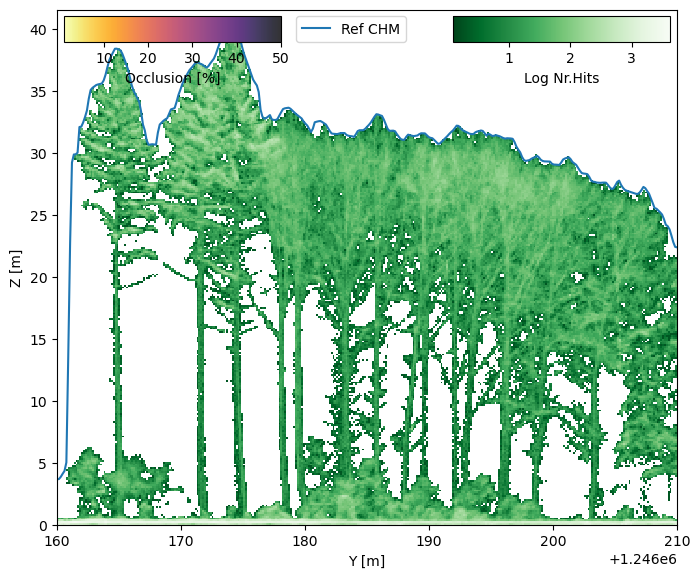

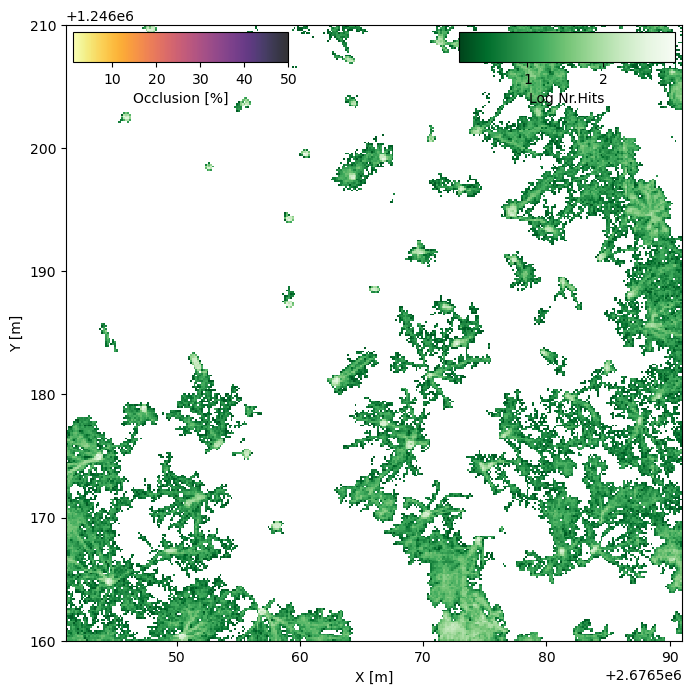

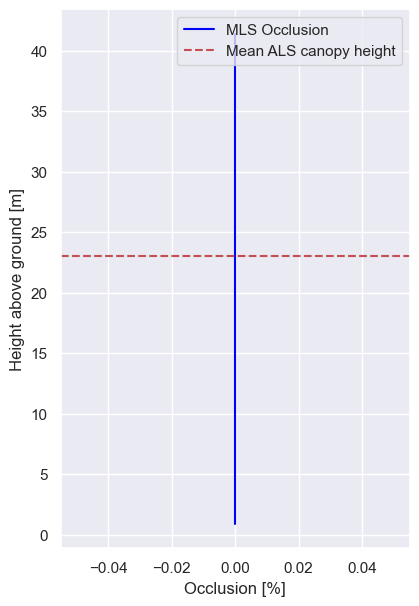

In [9]:
%matplotlib inline
test.get_Occl_TransectFigure(start_ind=200, end_ind=300, axis=0, show_plots=True)
test.get_Occl_TransectFigure(start_ind=200, end_ind=300, axis=1, show_plots=True)
test.get_Occl_TransectFigure(start_ind=50, end_ind=100, axis=2, show_plots=True)
occl_prof = test.get_Occlusion_Profile(show_plots=True)

We can also run this script from the command line. To control your inputs and parameters, edit the JSON accordingly. Note that by running the script via the command line, the plots will not be displayed per default but stored in the output folder.

In [ ]:
!python Test_Package_UAVLS.py settings_UAVLS.JSON